In [39]:
import pandas as pd
import glob

paths = glob.glob("../baseline_results/*.csv")
paths = [path for path in paths if 'results' not in path.split('/')[-1]]

#paths = [p for p in paths if "zheng" in p]

print(paths)
csv = pd.concat([pd.read_csv(path) for path in paths])
# Drop the ami_avg column
csv = csv.drop('ami_avg', axis=1)

csv.loc[csv.method == 'PCC5', 'method'] = 'MiCS+LMC'
csv.loc[csv.method == 'PCUMAP', 'method'] = 'UMAP+LMC'


csv.loc[csv.method == 'PCC2_No_Cluster', 'method'] = 'LMC'
csv.loc[csv.method == 'PCC2_No_Corr', 'method'] = 'MiCS'

csv = csv[~csv.method.str.contains('PCC', na=False)]


csv = csv[~csv.dataset.isin(["swiss_roll", "mammoth", "cifar", "cifar100", "mnist", "fashion_mnist"])]
# Drop the within_cluster_pr_avg column
csv = csv.drop('within_cluster_pr_avg', axis=1)


csv = csv.rename(columns={
    'within_cluster_pr_avg': 'Intra-cluster Mantel correlation',
    'between_centers_pr_avg': 'Centroid-level Mantel correlation',
    'mrre_false': 'MRRE Intrusions',
    'mrre_missing': 'MRRE Exclusions',
    'pearson_r': 'Mantel Distance Pearson Correlation',
    'spearman_rho': 'Mantel Distance Spearman Correlation',

})

# Rename methods to proper capitalization/formatting
method_renames = {
    'pca': 'PCA',
    'tsne': 't-SNE', 
    'umap': 'UMAP',
    'trimap': 'Trimap',
    'pacmac': 'PaCMAP',
    'dtne': 'DTNE',
    'phate': 'Phate',
    'localmap': 'LocalMAP'
}

csv['method'] = csv['method'].replace(method_renames)

['../baseline_results/mnist_tsne_1_result.csv', '../baseline_results/pancreas_baron_PCC_3_result.csv', '../baseline_results/macosko_PCC2_4_result.csv', '../baseline_results/zheng_PCC_No_Cluster_9_result.csv', '../baseline_results/visium_trimap_1_result.csv', '../baseline_results/visium_PCC2linear_cluster_weight05_0_result.csv', '../baseline_results/pbmc68k_pacmac_9_result.csv', '../baseline_results/pbmc3k_PCC4_8_result.csv', '../baseline_results/macosko_PCC2linear_cluster_weight08_8_result.csv', '../baseline_results/cifar_PCC6_7_result.csv', '../baseline_results/paul15_PCC2linear_cluster_weight0_4_result.csv', '../baseline_results/parkinsons_PCC3_4_result.csv', '../baseline_results/squidpy_visium_hne_PCC2_8_result.csv', '../baseline_results/zheng_PCC_No_Cluster_6_result.csv', '../baseline_results/macosko_PCC2_9_result.csv', '../baseline_results/pancreas_baron_localmap_3_result.csv', '../baseline_results/arcene_pca_6_result.csv', '../baseline_results/birthweight_PCC6_5_result.csv', '../

In [40]:
# Keep only UMAP and methods containing LMC or MiCS
csv = csv[csv.method.isin(['UMAP', 'MiCS+LMC', 'UMAP+LMC', 'LMC', 'MiCS'])]

# Compute means and stds over both seeds and datasets
metrics = csv.columns[3:]
methods = csv['method'].unique()
seeds = csv['seed'].unique()

# Initialize lists to store statistics
method_stats = []

for method in methods:
    method_data = csv[csv['method'] == method]
    
    # For each metric, compute:
    # 1. Mean over all data
    # 2. Std over seeds (averaging datasets first)
    # 3. Std over datasets (averaging seeds first)
    stats_row = {'method': method}
    
    for metric in metrics:
        # Overall mean across everything
        overall_mean = method_data[metric].mean()
        
        # Std over seeds
        # First average over datasets for each seed
        seed_means = method_data.groupby('seed')[metric].mean()
        seed_std = seed_means.std()
        
        # Std over datasets
        # First average over seeds for each dataset
        dataset_means = method_data.groupby('dataset')[metric].mean()
        dataset_std = dataset_means.std()
        
        stats_row[f'{metric}_mean'] = overall_mean
        stats_row[f'{metric}_seed_std'] = seed_std
        stats_row[f'{metric}_dataset_std'] = dataset_std
        
    method_stats.append(stats_row)

# Create DataFrame with method statistics
stats_df = pd.DataFrame(method_stats)

# Set method as index for easier access
stats_df = stats_df.set_index('method')

# Calculate overall mean of mean metrics for sorting
mean_cols = [col for col in stats_df.columns if col.endswith('_mean')]
stats_df['overall_mean'] = stats_df[mean_cols].mean(axis=1)

# Sort by overall mean and drop the temporary column
stats_df = stats_df.sort_values('overall_mean', ascending=False).drop('overall_mean', axis=1)

# Display first few rows
print("Created stats_df DataFrame with shape:", stats_df.shape)
stats_df


Created stats_df DataFrame with shape: (5, 21)


,trustworthiness_mean,trustworthiness_seed_std,trustworthiness_dataset_std,continuity_mean,continuity_seed_std,continuity_dataset_std,MRRE Intrusions_mean,MRRE Intrusions_seed_std,MRRE Intrusions_dataset_std,MRRE Exclusions_mean,...,MRRE Exclusions_dataset_std,Mantel Distance Pearson Correlation_mean,Mantel Distance Pearson Correlation_seed_std,Mantel Distance Pearson Correlation_dataset_std,Mantel Distance Spearman Correlation_mean,Mantel Distance Spearman Correlation_seed_std,Mantel Distance Spearman Correlation_dataset_std,Centroid-level Mantel correlation_mean,Centroid-level Mantel correlation_seed_std,Centroid-level Mantel correlation_dataset_std
method,,,,,,,,,,,,,,,,,,,,,
UMAP+LMC,0.926761,0.001526,0.087930,0.943475,0.002852,0.069820,0.885019,0.001342,0.099891,0.902127,...,0.098742,0.916720,0.002567,0.071572,0.920214,0.005513,0.065160,0.928020,0.003827,0.062083
MiCS+LMC,0.909090,0.001219,0.092090,0.935279,0.002283,0.057720,0.872607,0.002748,0.097569,0.904682,...,0.065196,0.922290,0.002369,0.068533,0.930907,0.003467,0.047120,0.909470,0.005756,0.069188
LMC,0.892185,0.001611,0.118537,0.911800,0.001434,0.097294,0.851485,0.002026,0.108478,0.875398,...,0.090328,0.927763,0.001579,0.066458,0.940271,0.001623,0.049018,0.884446,0.011345,0.093669
UMAP,0.894085,0.002860,0.115794,0.914809,0.003122,0.099656,0.863572,0.002016,0.124651,0.882790,...,0.116504,0.492903,0.007571,0.164370,0.532424,0.008705,0.226463,0.719212,0.011469,0.097295
MiCS,0.834399,0.004370,0.126089,0.845175,0.005276,0.114078,0.801208,0.004192,0.120977,0.812496,...,0.111997,0.291685,0.023531,0.117026,0.308170,0.027113,0.086518,0.511420,0.026437,0.096009


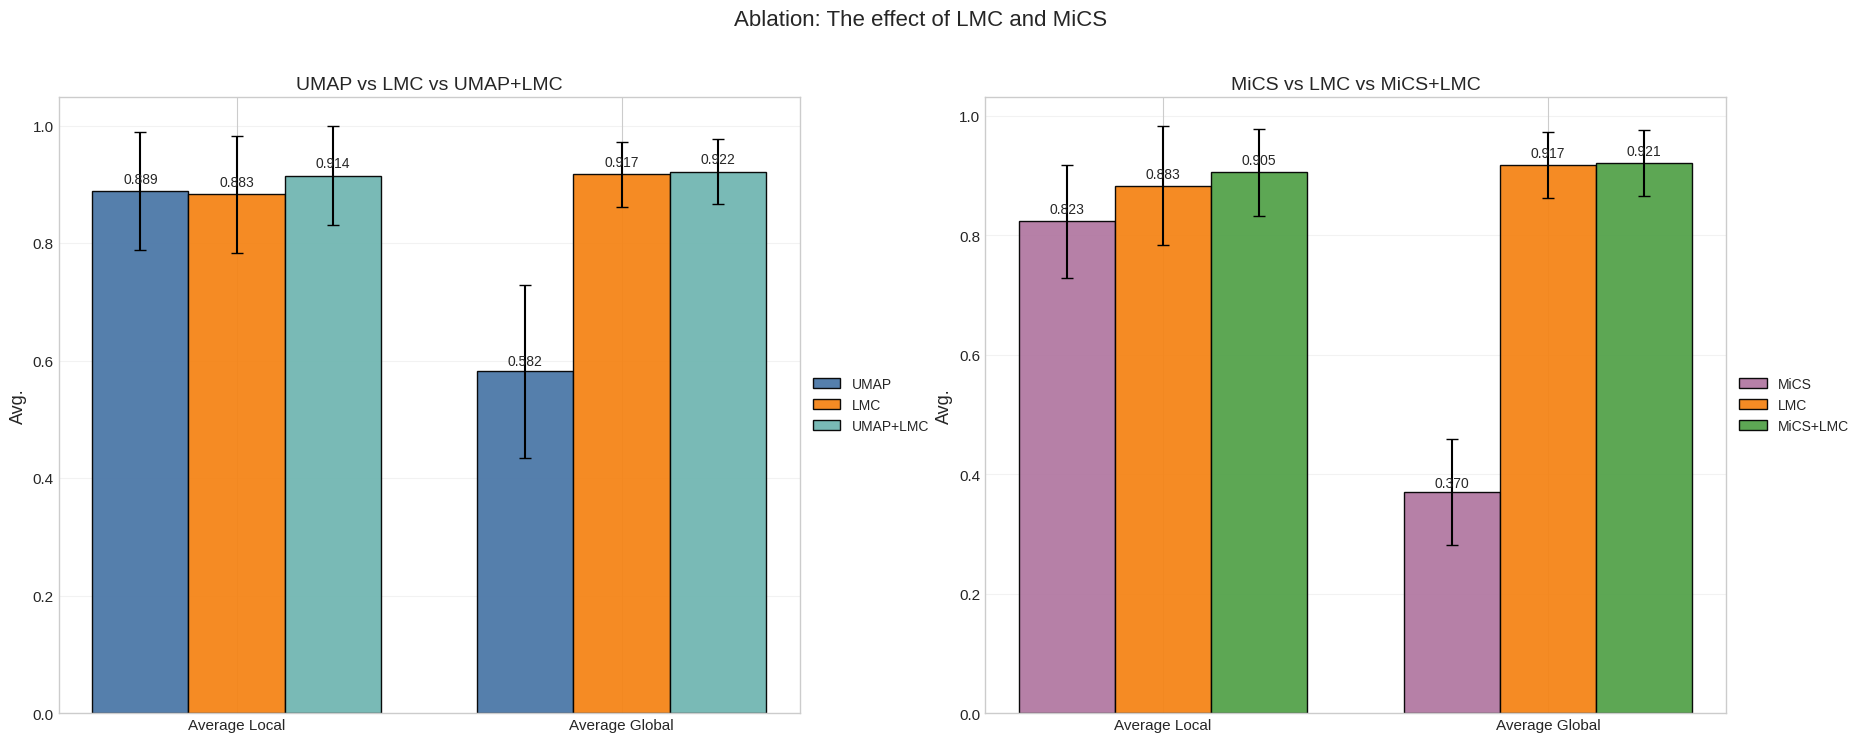

In [43]:
# --- Ablation trios (raw averages, dataset std) with nice colors & external legends ---
# Expects a DataFrame `csv` with columns:
# ['dataset','method','seed','trustworthiness','continuity',
#  'MRRE Intrusions','MRRE Exclusions',
#  'Mantel Distance Pearson Correlation','Mantel Distance Spearman Correlation',
#  'Centroid-level Mantel correlation']

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Iterable, Dict, Tuple, List

# ----------------------------
# Config
# ----------------------------
LOCAL_METRICS = [
    "trustworthiness",
    "continuity",
    "MRRE Intrusions",
    "MRRE Exclusions",
]
GLOBAL_METRICS = [
    "Mantel Distance Pearson Correlation",
    "Mantel Distance Spearman Correlation",
    "Centroid-level Mantel correlation",
]
# All metrics are treated as "higher is better" AND **not normalized**.

# Canonical method keys (mapped to actual names found in csv['method'])
CANON_TARGETS = {
    "UMAP": "umap",
    "UMAP+LMC": "umap+lmc",
    "LMC": "lmc",
    "MiCS": "mics",
    "MiCS+LMC": "mics+lmc",
}

# Elegant, paper-friendly colors
METHOD_COLORS = {
    "UMAP":        "#4C78A8",  # muted blue
    "UMAP+LMC":    "#72B7B2",  # teal
    "LMC":         "#F58518",  # amber
    "MiCS":        "#B279A2",  # plum
    "MiCS+LMC":    "#54A24B",  # green
}

# ----------------------------
# Helpers
# ----------------------------
def _ensure_columns_exist(df: pd.DataFrame, cols: Iterable[str]) -> None:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"DataFrame is missing required columns: {missing}")

def _norm_name(s: str) -> str:
    """Normalize a method name: drop text in parentheses, remove spaces, lowercase."""
    s = re.sub(r"\(.*?\)", "", str(s))  # drop "(ours)" etc.
    return s.replace(" ", "").lower()

def _match_canonical_methods(df: pd.DataFrame) -> Dict[str, str]:
    """
    Map canonical keys -> actual names in df['method'] using strict normalized equality,
    with a gentle substring fallback for the +LMC variants only.
    """
    avail = list(map(str, df["method"].unique()))
    norm_map = {_norm_name(m): m for m in avail}

    found = {}
    # strict equality first
    for canon, key in CANON_TARGETS.items():
        if key in norm_map:
            found[canon] = norm_map[key]

    # fallback for +LMC variants if strict not found
    for canon, key in CANON_TARGETS.items():
        if canon in found:
            continue
        if "+lmc" in key:  # only allow substring fallback for composite methods
            candidates = [m for m in avail if key in _norm_name(m)]
            if candidates:
                found[canon] = candidates[0]

    return found

def compute_local_global_raw_from_df(
    df: pd.DataFrame,
    local_metrics: Iterable[str] = None,
    global_metrics: Iterable[str] = None,
) -> pd.DataFrame:
    """
    RAW (non-normalized) aggregation.
    Steps:
      1) For each (dataset, method), average each metric over seeds.
      2) For each (dataset, method), compute LocalAvg_ds = mean(local metrics), GlobalAvg_ds = mean(global metrics).
      3) Across datasets, compute:
           - LocalAvg = mean(LocalAvg_ds)      (bar height)
           - GlobalAvg = mean(GlobalAvg_ds)    (bar height)
           - LocalData = std(LocalAvg_ds)      (yerr)
           - GlobalData = std(GlobalAvg_ds)    (yerr)
    Returns DataFrame indexed by method with columns: LocalAvg, GlobalAvg, LocalData, GlobalData.
    """
    local_metrics  = list(local_metrics)  if local_metrics  is not None else LOCAL_METRICS
    global_metrics = list(global_metrics) if global_metrics is not None else GLOBAL_METRICS

    required = ["dataset","method","seed"] + local_metrics + global_metrics
    _ensure_columns_exist(df, required)

    metrics_all = local_metrics + global_metrics

    # 1) Seed-averaged per (dataset, method)
    per_dm_mean = df.groupby(["dataset","method"])[metrics_all].mean()

    # 2) Per (dataset, method) aggregated local/global averages
    local_ds  = per_dm_mean[local_metrics].mean(axis=1)   # MultiIndex: (dataset, method)
    global_ds = per_dm_mean[global_metrics].mean(axis=1)

    # 3) Aggregate across datasets per method
    local_by_method  = local_ds.reset_index(name="LocalAvg_ds").groupby("method")["LocalAvg_ds"]
    global_by_method = global_ds.reset_index(name="GlobalAvg_ds").groupby("method")["GlobalAvg_ds"]

    out = pd.DataFrame({
        "LocalAvg":  local_by_method.mean(),
        "GlobalAvg": global_by_method.mean(),
        "LocalData": local_by_method.std(ddof=1),
        "GlobalData": global_by_method.std(ddof=1),
    })

    # ensure numeric dtype
    out = out.astype(float)
    return out

# ----------------------------
# Plotting
# ----------------------------
def plot_requested_trios_raw(csv: pd.DataFrame, title: str = "Ablation: The effect of LMC and MiCS"):
    """
    Left panel (exact order):   UMAP, LMC, UMAP+LMC (ours)
    Right panel (exact order):  MiCS, LMC, MiCS+LMC (ours)
    Y-axis: raw average scores across datasets (no normalization).
    Error bars: dataset std of the per-dataset averages.
    """
    required = ["dataset","method","seed"] + LOCAL_METRICS + GLOBAL_METRICS
    _ensure_columns_exist(csv, required)

    found = _match_canonical_methods(csv)

    left_order  = [found.get("UMAP"), found.get("LMC"), found.get("UMAP+LMC")]
    right_order = [found.get("MiCS"), found.get("LMC"), found.get("MiCS+LMC")]

    # Drop None entries (missing methods) but keep requested order
    left_methods  = [m for m in left_order  if m is not None]
    right_methods = [m for m in right_order if m is not None]

    if len(left_methods) == 0 and len(right_methods) == 0:
        raise ValueError("None of the requested methods were found in csv['method'].")

    # Compute raw aggregates once
    agg = compute_local_global_raw_from_df(csv)

    # Colors for actual method strings
    def _color_for(name: str) -> str:
        norm = _norm_name(name)
        for canon, key in CANON_TARGETS.items():
            if key == norm or (("+lmc" in key) and key in norm):
                return METHOD_COLORS.get(canon, None)
        return None

    # Styling — journal friendly
    plt.rcParams.update({
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "axes.linewidth": 1.0,
    })

    fig, axes = plt.subplots(1, 2, figsize=(23, 8), constrained_layout=False)
    fig.subplots_adjust(wspace=0.25, right=0.85)  # slightly less space for legends

    def _draw_trio(ax, methods, panel_title):
        cats = ["Average Local", "Average Global"]
        centers = np.arange(len(cats))
        width = 0.25 if len(methods) >= 3 else (0.32 if len(methods) == 2 else 0.5)

        handles, labels = [], []
        for j, m in enumerate(methods):
            vals = [
                float(agg.loc[m, "LocalAvg"]),
                float(agg.loc[m, "GlobalAvg"]),
            ]
            errs = [
                float(agg.loc[m, "LocalData"]),
                float(agg.loc[m, "GlobalData"]),
            ]
            pos = centers + (j - (len(methods)-1)/2.0)*width
            color = _color_for(m)
            bars = ax.bar(pos, vals, width=width, yerr=errs, capsize=4, linewidth=1.0,
                          label=m, color=color, edgecolor="black", alpha=0.95)
            handles.append(bars[0]); labels.append(m)

            # annotate values
            for x0, v in zip(pos, vals):
                ax.text(x0, v + 0.01 * max(0.1, v if np.isfinite(v) else 1.0),
                        f"{v:.3f}", ha="center", va="bottom", fontsize=10)

        ax.set_xticks(centers, cats)
        ax.set_ylabel("Avg.")
        ax.set_title(panel_title)
        ax.grid(axis="y", alpha=0.25)

        # Legend outside but closer to plot
        ax.legend(handles, labels, frameon=False, fontsize=10,
                  loc="center left", bbox_to_anchor=(1.01, 0.5), borderaxespad=0.0)

    _draw_trio(axes[0], left_methods,  "UMAP vs LMC vs UMAP+LMC")
    _draw_trio(axes[1], right_methods, "MiCS vs LMC vs MiCS+LMC")

    fig.suptitle(title, y=0.99, fontsize=16)
    plt.show()
    return fig, axes

# ----------------------------
# Example usage in your notebook:
fig, axes = plot_requested_trios_raw(csv)
fig.savefig("ablation.png", dpi=400, bbox_inches="tight")
